## Circuit Fitting

In [1]:
import impedance
import pandas as pd
import matplotlib.pyplot as plt
from impedance.models.circuits import CustomCircuit

In [52]:
from impedance import preprocessing
# load data and extract the frequency, impedance columns
df = pd.read_excel(r"C:\Users\jake.tjalkens\OneDrive - Redwood Materials\Documents\eis\practice data\test EIS data Z3.xlsx")
freq = df['Frequency (Hz)'].values
Zreal = df["Z' (Ω)"].values
Zimag = -df["-Z'' (Ω)"].values

# create complex number array for NyQuist plot
Z = Zreal + 1j * Zimag

In [53]:
# to build a circuit, use dash "-" to indicate in series and "p(,)" to indicate in parallel. 
# so, a resistor in series to an RC in series to another RC would be defined as:

circuit = 'R0-p(R1,C1)-p(R2-W1,C2)'
initial_guess = [0.01, 0.01, 100, 0.01, 0.01, 100]

circuit = CustomCircuit(circuit, initial_guess=initial_guess)

# circuit.fit requires two inputs: (frequency, impedance). 
circuit.fit(freq, Z)

print(circuit)


Circuit string: R0-p(R1,C1)-p(R2-W1,C2)
Fit: True

Initial guesses:
     R0 = 1.00e-02 [Ohm]
     R1 = 1.00e-02 [Ohm]
     C1 = 1.00e+02 [F]
     R2 = 1.00e-02 [Ohm]
     W1 = 1.00e-02 [Ohm sec^-1/2]
     C2 = 1.00e+02 [F]

Fit parameters:
     R0 = 7.31e-02  (+/- 6.78e-02) [Ohm]
     R1 = 2.54e+02  (+/- 2.37e+02) [Ohm]
     C1 = 8.86e-01  (+/- 4.39e-01) [F]
     R2 = 1.11e-01  (+/- 1.73e+01) [Ohm]
     W1 = 7.56e-01  (+/- 3.22e+00) [Ohm sec^-1/2]
     C2 = 2.03e+00  (+/- 1.41e+01) [F]



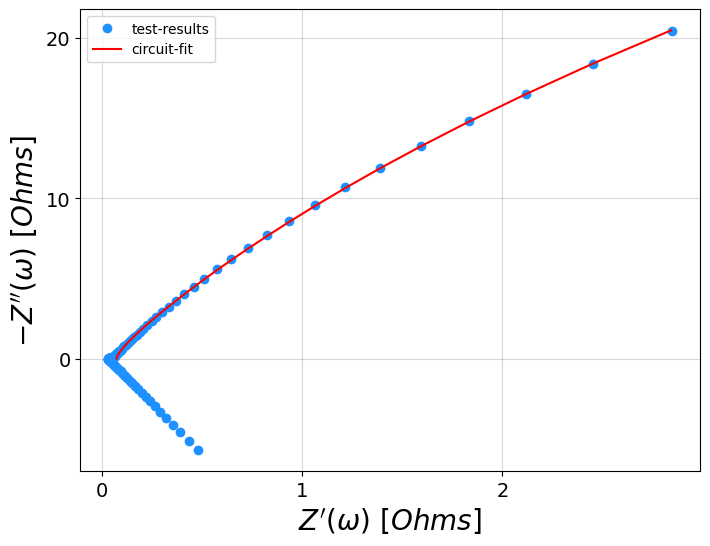

In [54]:
from impedance.visualization import plot_nyquist

Z_fit = circuit.predict(freq)

fig, ax = plt.subplots(figsize=(8,6))
plot_nyquist(Z, fmt='o', scale=1, ax=ax, label='test-results', color = 'dodgerblue')
plot_nyquist(Z_fit, fmt='-', scale=1, ax=ax, label='circuit-fit', color='red')

ax.set_aspect('auto')
plt.legend()
plt.show()